In [1]:
# Set up the file path, import packages, and define device
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(parent_dir)
print('Parent directory set to:', parent_dir)

# Import general packages
import torch
import numpy as np
from itertools import product, combinations_with_replacement
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.utils.ic import IC

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

# Import Visualization packages
from RL4CRN.utils.visualizations import plot_reactant_product_heatmap, plot_reactant_product_scatter, topology_graph

target_directory = os.path.join(parent_dir, '/local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE')

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
N_CPUs = os.cpu_count() if os.cpu_count() is not None else 1
print(f'Number of CPUs available: {os.cpu_count()}') 

Parent directory set to: /local0/scratch/git/CRN-GenerativeAI
Using device: cuda
Number of CPUs available: 8


In [2]:
# Flag to resimulate the IOCRN dynamics of the halls of fame
resimulate_flag = False 

# Flag to load generated IOCRNs from trained models
generated_flag = True

# Flag for filtering out repeated IOCRN topologies
filter_flag = True
num_reactions_template = 2

# Parallel simulation flag
parallel_flag = True

# Set number of inputs and species labels
p = 2                                                   # Number of inputs
species_labels = ['X_1', 'Z_1', 'Z_2', 'Z_3']                  # Species labels
mak_order = 2                                           # Maximum order of the mass-action reactions

# Hyperparameters
max_added_reactions = 6                             # Maximum number of reactions
N_CPUs = 4 # os.cpu_count()                         # Number of CPUs          
N = 160                                             # Number of samples (batch size)    
width = 1024                                        # Width of the neural networks  
depth = 5                                           # Depth of the neural networks 
deep_layer_size = 1024*10                           # Size of the deep layer encoding the CRNs
allow_input_influence = False                       # Allow input influence in the policy
learning_rate = 1e-4                                # Learning rate for the optimizer 
hall_of_fame_size = 30                              # Size of the hall of fame  
entropy_scheduler = {                               # Entropy scheduler parameters 
    'entropy_weight': 5e-3, 
    'topk_entropy_weight' : 1.0,
    'remainder_entropy_weight' : 1.0,
    'entropy_update_coefficient': 1, 
    'entropy_schedule': 1000, 
    'minimum_entropy_weight': 0.0
}
entropy_weights_per_head = {'structure': 3.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0} 
structure_head_temperature = {"target_entropy_ratio_to_max": np.log(5)/np.log(5), "initial_temperature": 1.0, "rate": 0.0, "current_temperature": 1.0}
risk_scheduler = {                                  # Risk scheduler parameters
    'risk': 0.90, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 1000
}
epoch_num = 600                                     # Number of epochs for training
render_schedule = 10                                # Render every # of epochs
render_mode = {                                     # Mode of the experiment
    'style': 'logger', 
    'task': 'SSA_transients', 
    'format': 'image',
    'topology': True,
    'bounds': [25]
}
# Ordering specific parameters
ordering_parameters = {
    'enforce_ordering': False,
    'constraint_weight' : float('inf')
}
# SIL settings
sil_settings = {
    'sil_loss_weight': 1.0,
    'sil_use_adaptive_baseline': False,
    'sil_baseline_annealing_rate': 0.95
}

render_n_best = 10                                                     # Number of best CRNs to plot responses for
render_disregard_percentage = risk_scheduler['risk']                  # Percentage of worst CRNs to disregard in the responses plotting

# Parameter distribution for the reactions added by the agent
continuous_distribution = {"type": 'lognormal_1D'}        

# Time horizon for the simulation
t_f = 100                                           # Final time for the simulation
N_t = 100                                          # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
scale = 3.0
nums = [1, 2, 3]
disturbances = [0.5, 1, 1.5]
u_list = [np.array(u) for u in product(nums, disturbances)] # list of input combinations, each input is a numpy array of shape (p,)

print(u_list)

# Construct the reference setpoints
r_list = [np.array([u[0]])*scale for u in u_list]
print(r_list)   

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.0, 0.0, 0.0, 0.0]]) 

# Define path for the directories: hall of fame and models
base_path_hof = os.path.abspath(os.path.join(target_directory, 'hof'))
base_path_models = os.path.abspath(os.path.join(target_directory, 'models'))
print(f"Current working directory: {os.getcwd()}")
print(f"Base path for halls of fame: {base_path_hof}")
print(f"Base path for models: {base_path_models}")

[array([1. , 0.5]), array([1, 1]), array([1. , 1.5]), array([2. , 0.5]), array([2, 1]), array([2. , 1.5]), array([3. , 0.5]), array([3, 1]), array([3. , 1.5])]
[array([3.]), array([3.]), array([3.]), array([6.]), array([6.]), array([6.]), array([9.]), array([9.]), array([9.])]
Current working directory: /local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/plots
Base path for halls of fame: /local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/hof
Base path for models: /local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/models


In [3]:
# Collect IOCRNs from halls of fame and those generated by trained models
# Get list of hall of fame files
hof_files = [f for f in os.listdir(base_path_hof) if f.startswith('hall_of_fame_') and f.endswith('.pth')]
print(f"Found {len(hof_files)} hall of fame files:")
for file in hof_files:
    print(f"- {file}")
print("-" * 40)

# Get list of generated files
generated_files = [f for f in os.listdir(base_path_models) if f.startswith('generated') and f.endswith('.pth')]
print(f"Found {len(generated_files)} generated files:")
for file in generated_files:
    print(f"- {file}")
print("-" * 40)

# Load the list of IOCRNs from each hall of fame file
hof_data = {}
for file in hof_files:
    file_path = os.path.join(base_path_hof, file)
    hof_data[file] = torch.load(file_path, weights_only=False)
    print(f"Loaded {file} with {len(hof_data[file])} entries.")

# Collect all IOCRNs from the halls of fame into a single list
hof_iocrns = []
for file, iocrn_list in hof_data.items():
    hof_iocrns.extend(iocrn_list)
print("-" * 40)
print(f"Total IOCRNs collected from all halls of fame: {len(hof_iocrns)}")
print("-" * 40)

if generated_flag:
    # Load the list of generated IOCRNs
    generated_data = {}
    for file in generated_files:
        file_path = os.path.join(base_path_models, file)
        generated_data[file] = torch.load(file_path, weights_only=False)
        print(f"Loaded {file} with {len(generated_data[file])} entries.")

    # Collect all IOCRNs from the generated files into a single list
    generated_iocrns = []
    for file, iocrn_list in generated_data.items():
        generated_iocrns.extend(iocrn_list)
    print("-" * 40)
    print(f"IOCRNs collected from all generated files: {len(generated_iocrns)}")
    generated_iocrns = [crn for crn in generated_iocrns if crn.last_task_info.get('reward', None) is not None]

# Collect all IOCRNs into a single list
all_iocrns = [crn for crn in hof_iocrns if crn.last_task_info.get('reward', None) is not None]


if generated_flag:
    all_iocrns.extend(generated_iocrns)
print("-" * 40)
print(f"Total IOCRNs: {len(all_iocrns)}")



Found 3 hall of fame files:
- hall_of_fame_2025-12-15 09:43:09.pth
- hall_of_fame_2025-12-23 09:48:40.pth
- hall_of_fame_2025-12-12 11:03:06.pth
----------------------------------------
Found 3 generated files:
- generated_2025-12-23 09:48:40.pth
- generated_2025-12-12 11:03:06.pth
- generated_2025-12-15 09:43:09.pth
----------------------------------------
Loaded hall_of_fame_2025-12-15 09:43:09.pth with 30 entries.
Loaded hall_of_fame_2025-12-23 09:48:40.pth with 30 entries.
Loaded hall_of_fame_2025-12-12 11:03:06.pth with 30 entries.
----------------------------------------
Total IOCRNs collected from all halls of fame: 90
----------------------------------------
Loaded generated_2025-12-23 09:48:40.pth with 160 entries.
Loaded generated_2025-12-12 11:03:06.pth with 160 entries.
Loaded generated_2025-12-15 09:43:09.pth with 160 entries.
----------------------------------------
IOCRNs collected from all generated files: 480
----------------------------------------
Total IOCRNs: 567


In [4]:
# Resimulate the dynamics of each IOCRN if the flag is set
if resimulate_flag:
    print("Resimulating IOCRN dynamics...")

    # Reset all IOCRNs
    for iocrn in all_iocrns:
        iocrn.reset()

    # Simulate each IOCRN
    if parallel_flag:
        results = Parallel(n_jobs=N_CPUs)(delayed(compute_reward)(iocrn) for iocrn in all_iocrns) 
    else:
        results = []
        for iocrn in all_iocrns:
            results.append(compute_reward(iocrn))

    # Unzip the results
    rewards_list, last_task_info_list = zip(*results)
    rewards_list = list(rewards_list)
    last_task_info_list = list(last_task_info_list)

    # Update the last task info in each IOCRN since running in parallel does not modify the IOCRNs themselves
    for i, iocrn in enumerate(all_iocrns):
        iocrn.last_task_info = last_task_info_list[i]            

Filtering topologically unique IOCRNs...
Number of topologically unique IOCRNs: 548 out of 567 total IOCRNs.


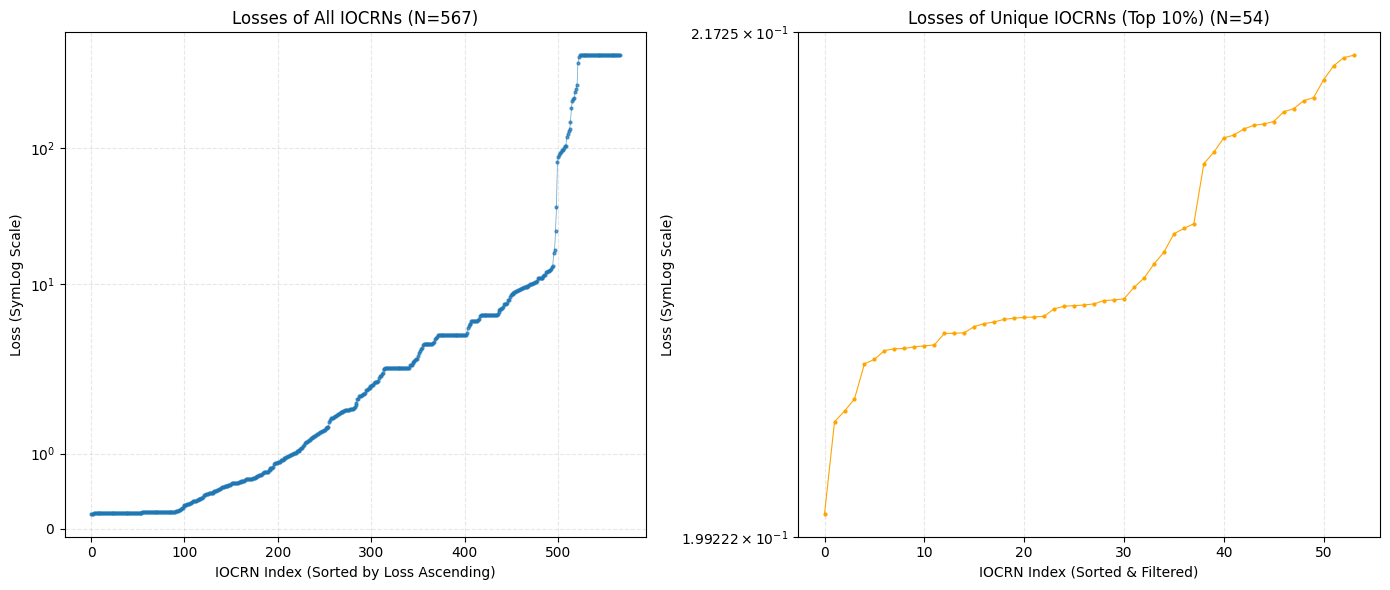

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_unique_rewards(all_iocrns, filter_flag=True, top_percentile=100, figsize=(14, 6)):
    """
    Sorts IOCRNs by reward (loss), optionally filters for topological uniqueness, 
    and plots the reward distribution.

    Args:
        all_iocrns (list): List of IOCRN objects. Each must have .last_task_info['reward'] 
                           and .is_topologically_equal().
        filter_flag (bool): If True, removes topologically duplicate CRNs, keeping the 
                            best-performing version of each topology.
        top_percentile (float): If < 100, restricts the "Unique" plot to the top X% 
                                of topologies. (e.g., 10 = top 10%).
        figsize (tuple): Figure size for the plot.
    """
    
    # 1. Sort all IOCRNs by reward/loss.
    # User Request: "Plotting a loss" -> "Lower values on the left".
    # This implies Ascending Order (Smallest/Best -> Largest/Worst).
    all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)

    # 2. Filter topologically unique IOCRNs
    if filter_flag:
        print("Filtering topologically unique IOCRNs...")
        all_iocrns_sorted_filtered = []
        
        if all_iocrns_sorted:
            # The list is sorted [Best, ..., Worst].
            # To keep the BEST version of each topology, we iterate FORWARD.
            # The first time we see a topology, it is the best one (lowest index in sorted list).
            unique_indices = []
            seen_topologies = []
            
            for i in range(len(all_iocrns_sorted)):
                candidate = all_iocrns_sorted[i]
                is_new = True
                for seen in seen_topologies:
                    if candidate.is_topologically_equal(seen):
                        is_new = False
                        break
                
                if is_new:
                    seen_topologies.append(candidate)
                    unique_indices.append(i)
            
            all_iocrns_sorted_filtered = [all_iocrns_sorted[i] for i in unique_indices]
            
        print(f"Number of topologically unique IOCRNs: {len(all_iocrns_sorted_filtered)} out of {len(all_iocrns_sorted)} total IOCRNs.")

    else:
        all_iocrns_sorted_filtered = all_iocrns_sorted

    # 3. Apply Percentile Cutoff (to the Filtered list)
    if top_percentile < 100:
        n_total = len(all_iocrns_sorted_filtered)
        n_keep = max(1, int(n_total * (top_percentile / 100.0)))
        
        # Keep the FIRST n_keep items (Lowest Loss / Best Performance)
        all_iocrns_sorted_filtered = all_iocrns_sorted_filtered[:n_keep]
        title_suffix = f" (Top {top_percentile}%)"
    else:
        title_suffix = ""

    # 4. Extract Rewards
    rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]
    rewards_sorted_filtered = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted_filtered]

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Left Plot: All IOCRNs
    ax1.plot(rewards_sorted, marker='o', markersize=2, linestyle='-', linewidth=0.5, alpha=0.7)
    ax1.set_yscale('symlog') # symlog handles negative rewards better than log
    ax1.set_xlabel('IOCRN Index (Sorted by Loss Ascending)')
    ax1.set_ylabel('Loss (SymLog Scale)')
    ax1.set_title(f'Losses of All IOCRNs (N={len(rewards_sorted)})')
    ax1.grid(True, which="both", ls="--", alpha=0.3)

    # Right Plot: Unique / Top Percentile
    ax2.plot(rewards_sorted_filtered, marker='o', color='orange', markersize=2, linestyle='-', linewidth=0.8)
    ax2.set_yscale('symlog') # Kept as symlog
    ax2.set_xlabel('IOCRN Index (Sorted & Filtered)')
    ax2.set_ylabel('Loss (SymLog Scale)')
    ax2.set_title(f'Losses of Unique IOCRNs{title_suffix} (N={len(rewards_sorted_filtered)})')
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    
    # Ensure tick labels are visible on Y axis
    ax2.yaxis.set_minor_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    plt.show()

    return all_iocrns_sorted, all_iocrns_sorted_filtered

# Plot the rewards with filtering and top percentile options
all_iocrns_sorted, all_iocrns_sorted_filtered = plot_unique_rewards(all_iocrns, filter_flag=filter_flag, top_percentile=10, figsize=(14, 6))

In [6]:
# Select the top IOCRNs and top topologically unique IOCRNs to visualize
n_unfiltered = 100
n_filtered = 30

In [7]:
ic = IC(names=species_labels, values=[[0.0, 0.0, 0.0, 0.0]])

sorting...
done ... 
Unfiltered: IOCRN # 100 has a reward of 0.3029468814203861


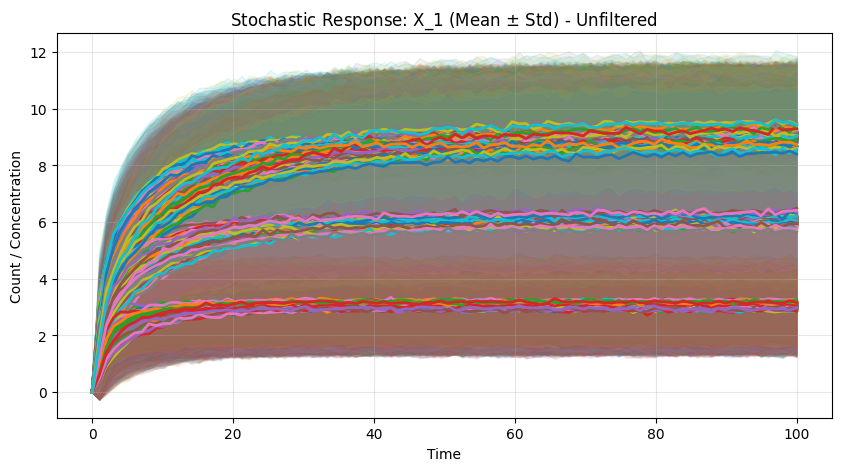

In [8]:
# Plot the responses of the top IOCRNs (topologically not unique)
ax = None
print("sorting...")
all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)
print("done ... ")
for i in range(n_unfiltered):
    x0_list = ic.get_ic(all_iocrns_sorted[i])
    fig, ax = all_iocrns_sorted[i].plot_SSA_transient_response(axes=ax, alpha=0.1)
ax[0].set_title(ax[0].get_title() + ' - Unfiltered')
# remove legend 
ax[0].legend_.remove()

print(f'Unfiltered: IOCRN # {n_unfiltered} has a reward of {all_iocrns_sorted[n_unfiltered-1].last_task_info["reward"]}')

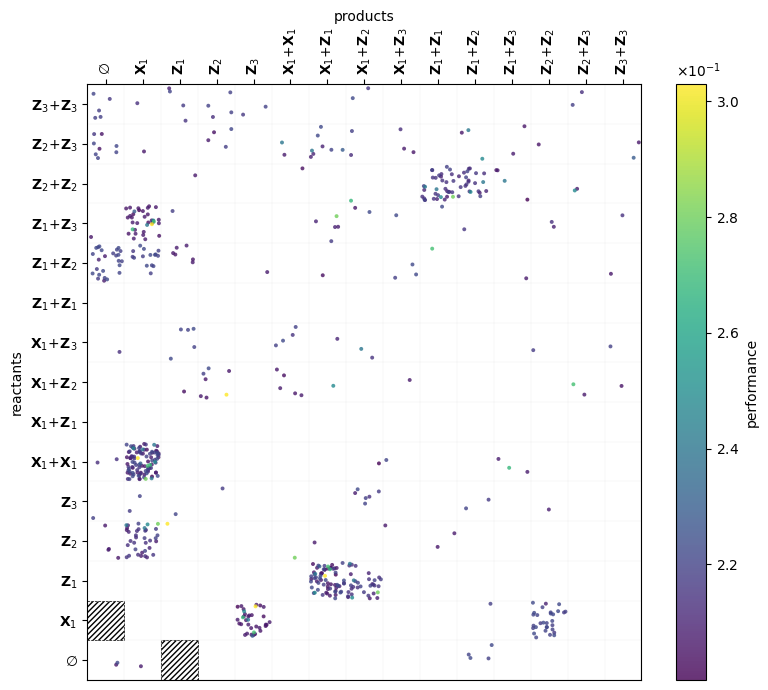

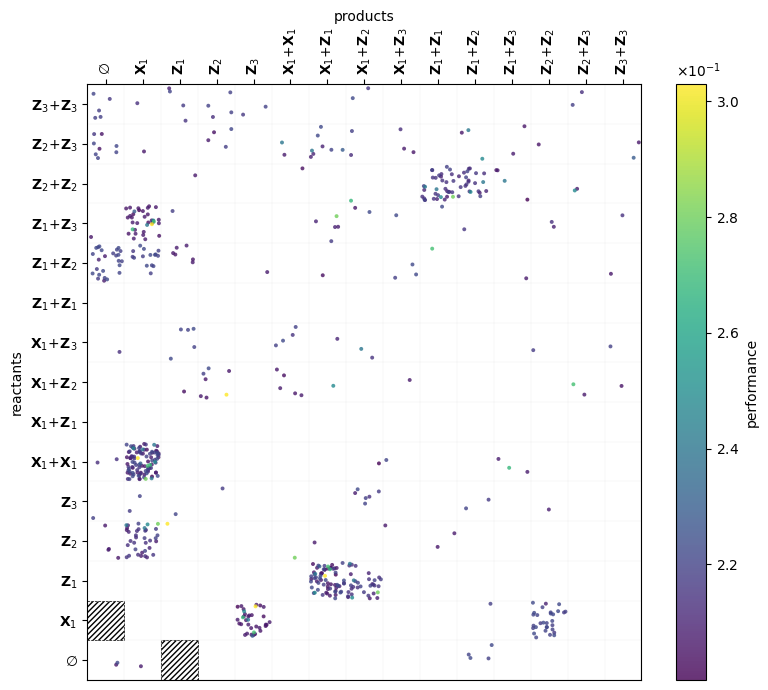

In [18]:
# Plot the reactant-product scatter for the top unfiltered IOCRNs
rewards_sorted = [iocrn.last_task_info.get('reward') for iocrn in all_iocrns_sorted]

plot_reactant_product_scatter(
    all_iocrns_sorted[0:n_unfiltered],
    perf=rewards_sorted[0:n_unfiltered],
    species_labels=species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=20,
    # figsize=(6, 5),
    jitter_scale=0.45,
    use_plotly=False  # <--- ENABLE INTERACTIVE PLOTTING WITH PLOTLY
)

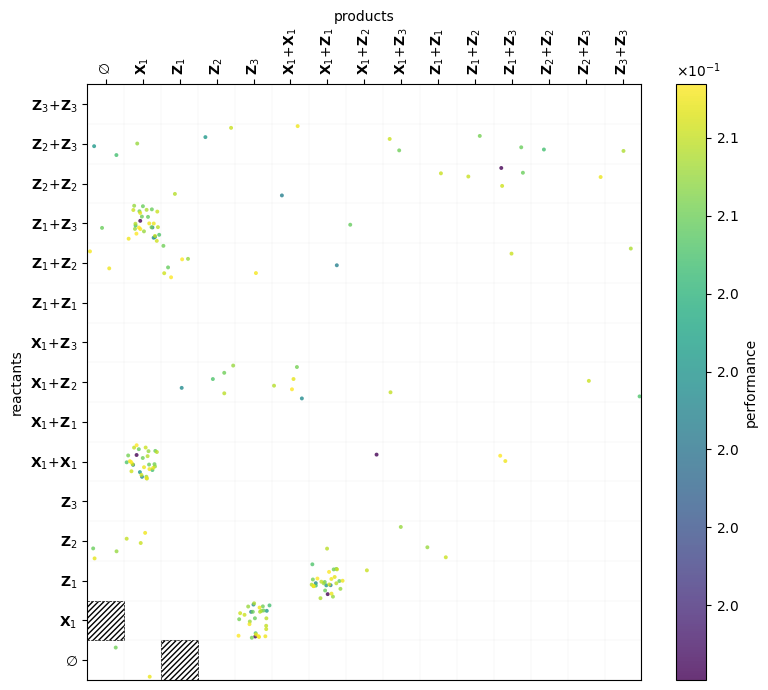

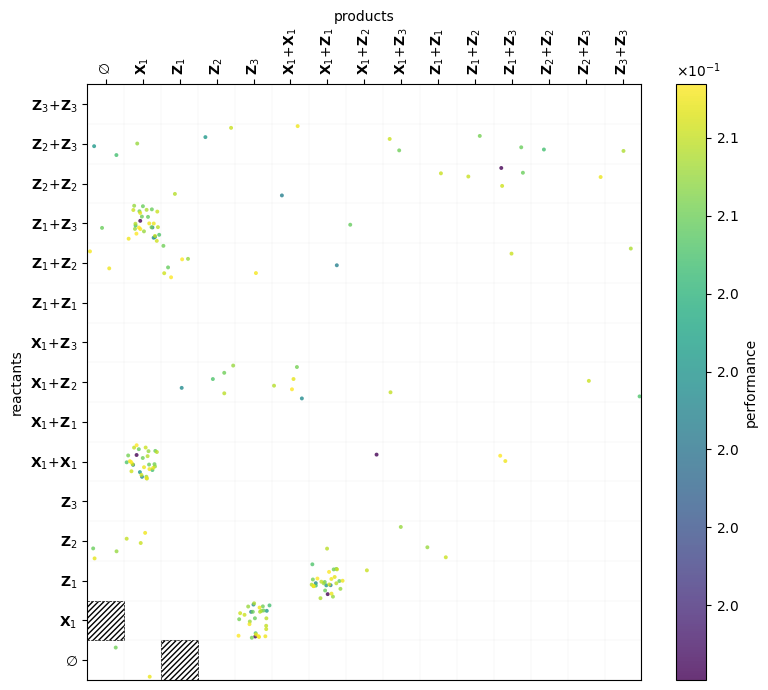

In [19]:
# Plot the reactant-product scatter for the top unfiltered IOCRNs
rewards_sorted_filtered = [iocrn.last_task_info.get('reward') for iocrn in all_iocrns_sorted_filtered]

plot_reactant_product_scatter(
    all_iocrns_sorted_filtered[0:n_filtered],
    perf=rewards_sorted_filtered[0:n_filtered],
    species_labels=species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=20,
    # figsize=(6, 5),
    jitter_scale=0.45,
    use_plotly=False  # <--- ENABLE INTERACTIVE PLOTTING WITH PLOTLY
)

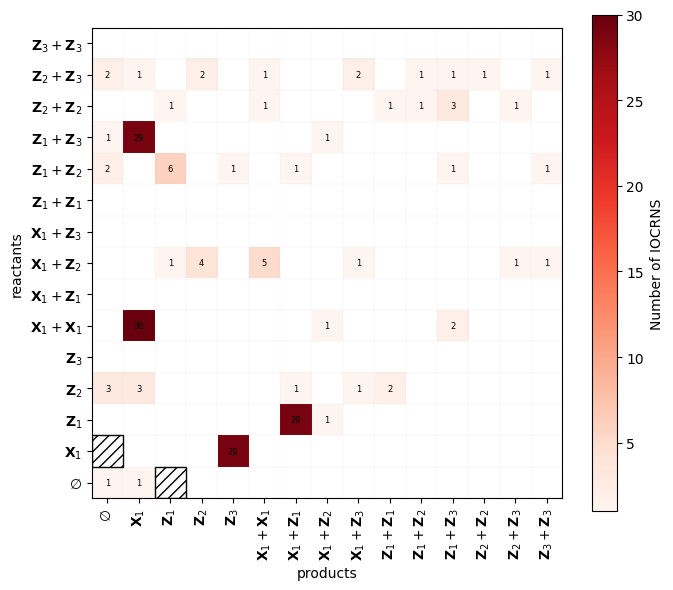

In [27]:
# Plot the reactant-product heatmap for the top filtered IOCRNs (topologically unique)
plot_reactant_product_heatmap(
    all_iocrns_sorted_filtered[0:n_filtered],
    species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="Reds",
    max_ticks=20,
    figsize=(7, 6),
)

Applied reward weighting (alpha=10.0). Edges stretched by fitness gaps.
Computing layout (mds)...
Dual Coloring: Face=Loss (Greyscale), Edge=Cluster (Rainbow) with Black Separator


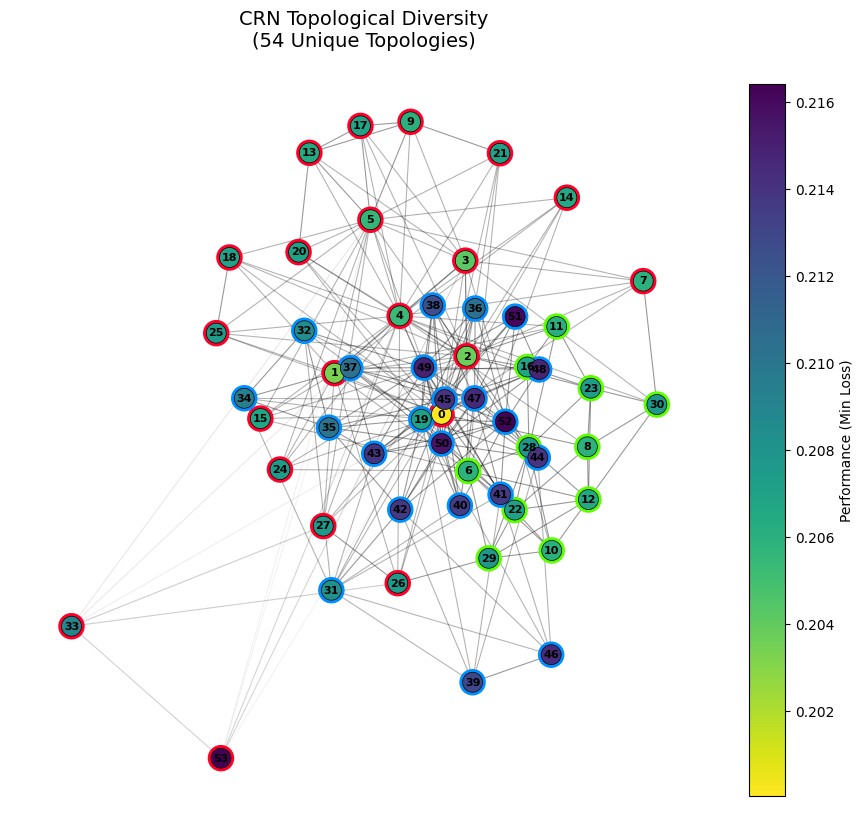

In [43]:
from RL4CRN.utils.visualizations import visualize_crn_diversity
rewards_sorted_filtered = [iocrn.last_task_info.get('reward') for iocrn in all_iocrns_sorted_filtered]
# use unique filtered iocrns
visualize_crn_diversity(all_iocrns_sorted_filtered, perf=rewards_sorted_filtered, t=10, layout_method="mds", label_percentile=50, alpha=10.0, unique=True)  # <--- ENABLE REWARD-WEIGHTED TOPOLOGY WITH ALPHA=10.0

In [37]:
print(all_iocrns_sorted_filtered[0])

Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1', 'Z_2', 'Z_3'] 
Output Species: ['X_1'] 
∅ ----> Z_1;  [MAK(3.0, u_1)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
X_1 ----> Z_3;  [MAK(0.9901369214057922)]
Z_1 ----> X_1 + Z_1;  [MAK(0.9587675929069519)]
X_1 + X_1 ----> X_1;  [MAK(1.1058326959609985)]
X_1 + X_1 ----> X_1 + Z_2;  [MAK(1.7381806373596191)]
Z_1 + Z_3 ----> X_1;  [MAK(1.173643946647644)]
Z_2 + Z_2 ----> Z_1 + Z_3;  [MAK(1.564497947692871)]


In [41]:
print(all_iocrns_sorted_filtered[39])

Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1', 'Z_2', 'Z_3'] 
Output Species: ['X_1'] 
∅ ----> Z_1;  [MAK(3.0, u_1)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
Z_1 ----> X_1 + Z_2;  [MAK(6.379960536956787)]
Z_2 ----> X_1;  [MAK(1.3904197216033936)]
X_1 + X_1 ----> ∅;  [MAK(1.6627918481826782)]
X_1 + X_1 ----> X_1;  [MAK(7.024473190307617)]
Z_2 + Z_2 ----> Z_1 + Z_1;  [MAK(9.732991218566895)]
Z_2 + Z_3 ----> X_1 + Z_3;  [MAK(1.569952368736267)]


In [42]:
print(all_iocrns_sorted_filtered[30])

Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1', 'Z_2', 'Z_3'] 
Output Species: ['X_1'] 
∅ ----> Z_1;  [MAK(3.0, u_1)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
X_1 ----> Z_3;  [MAK(0.9958142638206482)]
Z_1 ----> X_1 + Z_1;  [MAK(1.1426575183868408)]
Z_2 ----> ∅;  [MAK(1.374594807624817)]
X_1 + X_1 ----> X_1;  [MAK(1.475437879562378)]
Z_1 + Z_3 ----> X_1;  [MAK(1.0381546020507812)]
Z_2 + Z_3 ----> Z_1 + Z_3;  [MAK(0.7965973615646362)]
